### Análise exploratória sobre emissão de CO2

https://www.kaggle.com/datasets/thedevastator/global-fossil-co2-emissions-by-country-2002-2022

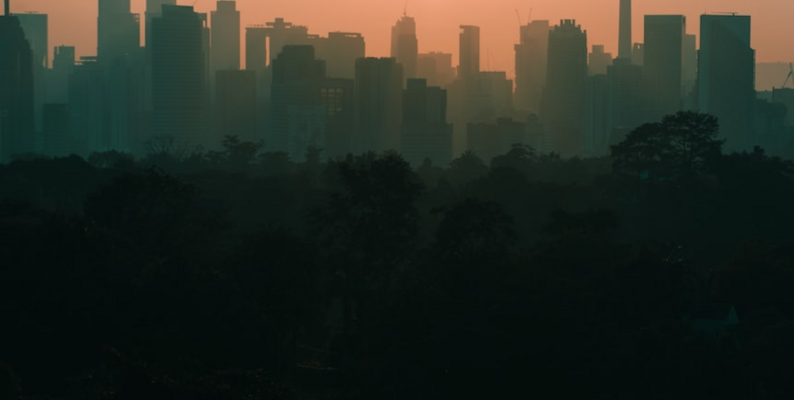

## Download

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/global-fossil-co2-emissions-by-country-2002-2022")

print("Path to dataset files:", path)

100%|██████████| 1.71M/1.71M [00:01<00:00, 1.38MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/global-fossil-co2-emissions-by-country-2002-2022/versions/4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv(path + '/' + 'GCB2022v27_MtCO2_flat.csv')
df

,Country,ISO 3166-1 alpha-3,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,Afghanistan,AFG,1750,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1751,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
63099,Global,WLD,2017,36096.739276,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682
63100,Global,WLD,2018,36826.506600,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753
63101,Global,WLD,2019,37082.558969,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633
63102,Global,WLD,2020,35264.085734,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423


## EDA (Análise Exploratória de Dados)

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             63104 non-null  object 
 1   ISO 3166-1 alpha-3  61472 non-null  object 
 2   Year                63104 non-null  int64  
 3   Total               62904 non-null  float64
 4   Coal                21744 non-null  float64
 5   Oil                 21717 non-null  float64
 6   Gas                 21618 non-null  float64
 7   Cement              20814 non-null  float64
 8   Flaring             21550 non-null  float64
 9   Other               1620 non-null   float64
 10  Per Capita          18974 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 5.3+ MB


### analise

- consigo ver que o nome do pais e a ISo são textos o nome e a sigla do pais
- o ano é um inteiro
- todos os dados são floats de toneladas de CO2 e tem muitos dados nulos

In [ ]:
df.describe()

,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
count,63104.000000,62904.000000,21744.000000,21717.000000,21618.000000,20814.000000,21550.000000,1620.000000,18974.000000
mean,1885.500000,55.224788,73.968916,55.760624,23.504285,4.330443,1.712695,10.951389,4.413363
std,78.519728,824.845435,598.986992,519.034563,247.674772,50.305770,16.727067,39.034073,17.432815
min,1750.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1817.750000,0.000000,0.000000,0.091600,0.000000,0.000000,0.000000,0.520885,0.197866
50%,1885.500000,0.000000,0.271852,1.044240,0.000000,0.022756,0.000000,1.255329,1.303949
75%,1953.250000,0.549342,6.736411,8.339752,0.581628,0.568502,0.000000,4.385471,5.077994
max,2021.000000,37123.850352,15051.512770,12345.653374,7921.829472,1672.592372,439.253991,306.638573,834.192642


- count: Quantidade de valores válidos (não tem nenhum ano vazio mas métricas de poluição sim).

- mean: Média aritmética dos valores (media do total de toneladas de poluição é 55.224788).

- std: Desvio padrão (indica o quanto os dados se distanciam da média).

- min: O menor valor registrado na coluna.

- 25%, 50%, 75%: Os percentis (ou quartis),

- max: O maior valor registrado na coluna.

In [ ]:
df['Country']

,Country
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
...,...
63099,Global
63100,Global
63101,Global
63102,Global


In [ ]:
df.columns

Index(['Country', 'ISO 3166-1 alpha-3', 'Year', 'Total', 'Coal', 'Oil', 'Gas',
       'Cement', 'Flaring', 'Other', 'Per Capita'],
      dtype='object')

In [ ]:
paisCO2 = df.groupby('Country')['Total'].sum()
paisCO2

,Total
Country,
Afghanistan,217.993073
Albania,293.838988
Algeria,4862.566823
Andorra,15.484492
Angola,657.115491
...,...
Viet Nam,4623.865636
Wallis and Futuna Islands,0.773031
Yemen,651.596748


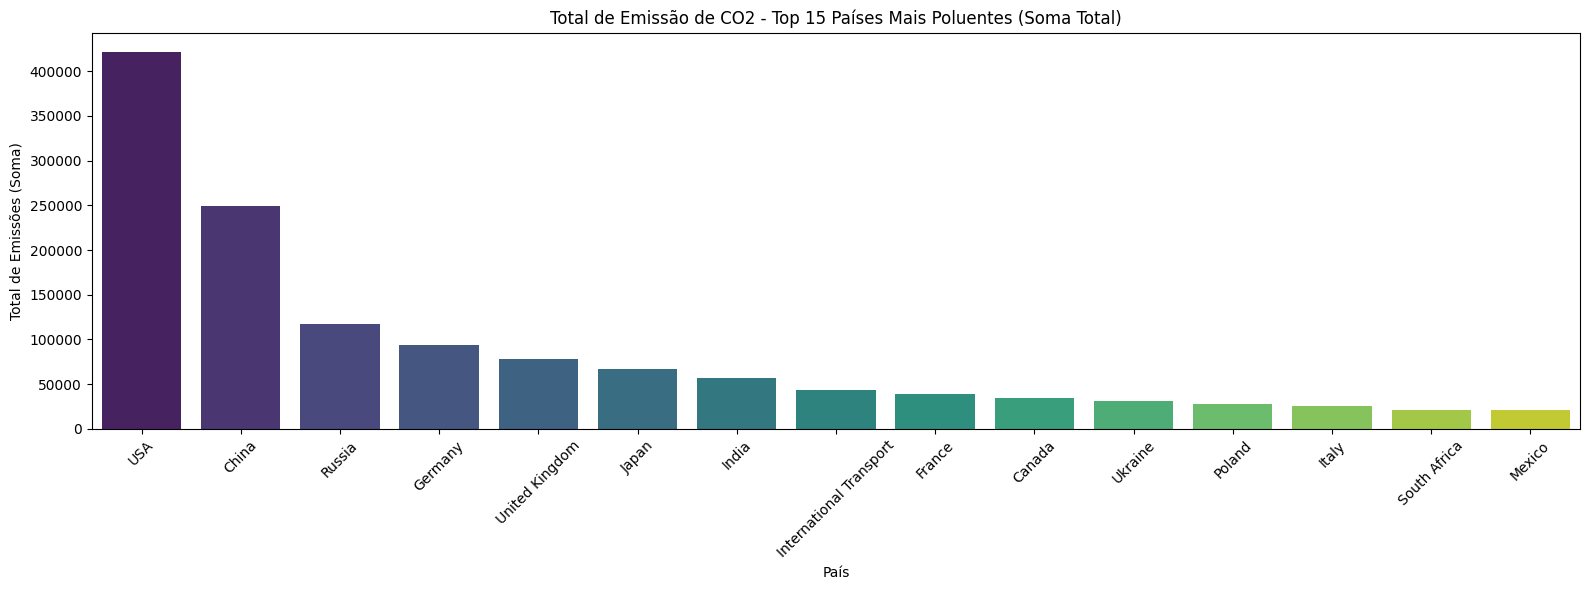

In [ ]:
df_grouped = (
    df[df['Country'] != 'Global'] # Remove o Global
    .groupby('Country')['Total']
    .sum()
    .nlargest(15)
    .reset_index()
)

df_grouped = df_grouped.sort_values(by='Total', ascending=False)

plt.figure(figsize=(16, 6))
plt.title('Total de Emissão de CO2 - Top 15 Países Mais Poluentes (Soma Total)')

sns.barplot(
    data=df_grouped,
    x='Country',
    y='Total',
    palette='viridis',
    hue='Country',
)

plt.xticks(rotation=45)
plt.ylabel('Total de Emissões (Soma)')
plt.xlabel('País')
plt.tight_layout()
plt.show()

In [ ]:
coal = df['Coal'].sum()
oil = df['Oil'].sum()
gas = df['Gas'].sum()
cement = df['Cement'].sum()
flaring = df['Flaring'].sum()
other = df['Other'].sum()


data = {
    'Coal': coal,
    'Oil': oil,
    'Gas': gas,
    'Cement': cement,
    'Flaring': flaring,
    'Other': other
}

# Criar um Series para facilitar a plotagem
series = pd.Series(data)
series

,0
Coal,1.608380e+06
Oil,1.210953e+06
Gas,5.081156e+05
Cement,9.013385e+04
Flaring,3.690857e+04
Other,1.774125e+04


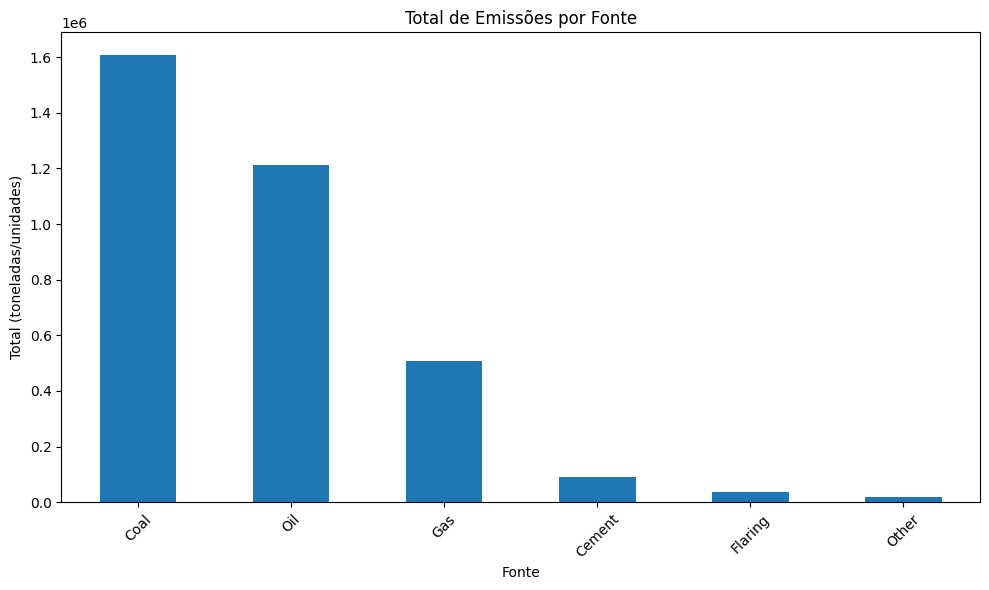

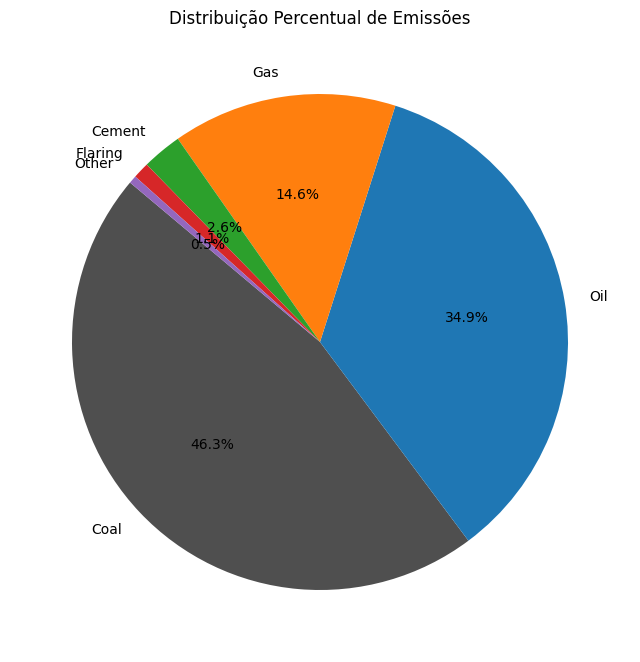

In [ ]:
plt.figure(figsize=(10, 6))
series.plot(kind='bar')
plt.title('Total de Emissões por Fonte')
plt.ylabel('Total (toneladas/unidades)')
plt.xlabel('Fonte')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.pie(series, labels=series.index, autopct='%1.1f%%', startangle=140, colors=['#4F4F4F', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Distribuição Percentual de Emissões')
plt.show()

In [ ]:
paisCO2 = df.groupby('Country')['Year'].max()
paisCO2

,Year
Country,
Afghanistan,2021
Albania,2021
Algeria,2021
Andorra,2021
Angola,2021
...,...
Viet Nam,2021
Wallis and Futuna Islands,2021
Yemen,2021


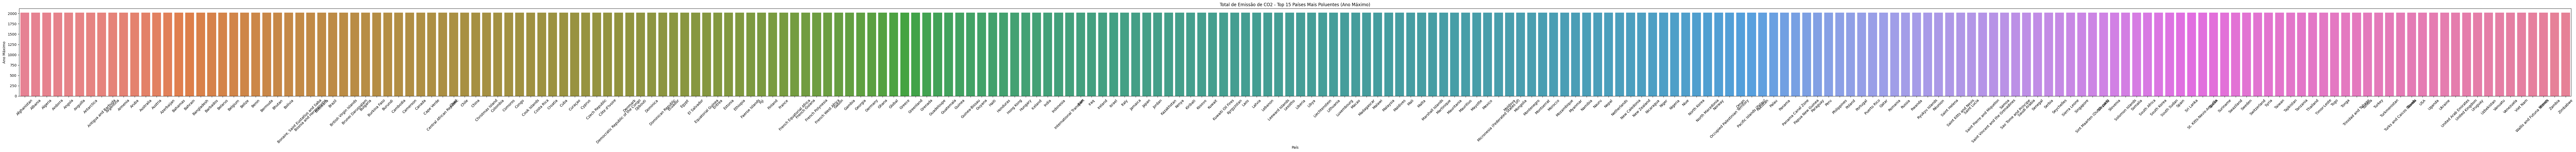

In [ ]:
# df_grouped = (
#     df.groupby('Country')['Year']
#     .max()
#     .nlargest(15)
#     .reset_index()
# )

# df_grouped = df_grouped.sort_values(by='Year', ascending=False)

plt.figure(figsize=(100, 6))
plt.title('Total de Emissão de CO2 - Top 15 Países Mais Poluentes (Ano Máximo)')

sns.barplot(
    data=df_grouped,
    x='Country',
    y='Year',
    hue='Country',
)

plt.xticks(rotation=45)
plt.ylabel('Ano Máximo')
plt.xlabel('País')
plt.tight_layout()
plt.show()

- a análise em questão foi inutil pois o maior